Dataset loaded successfully!
Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   



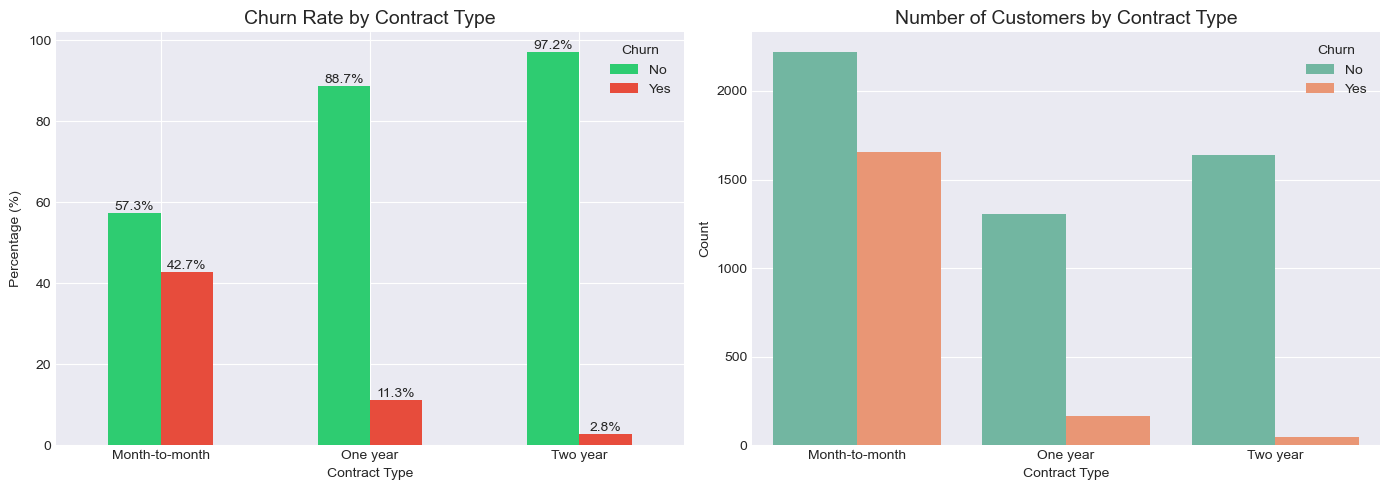

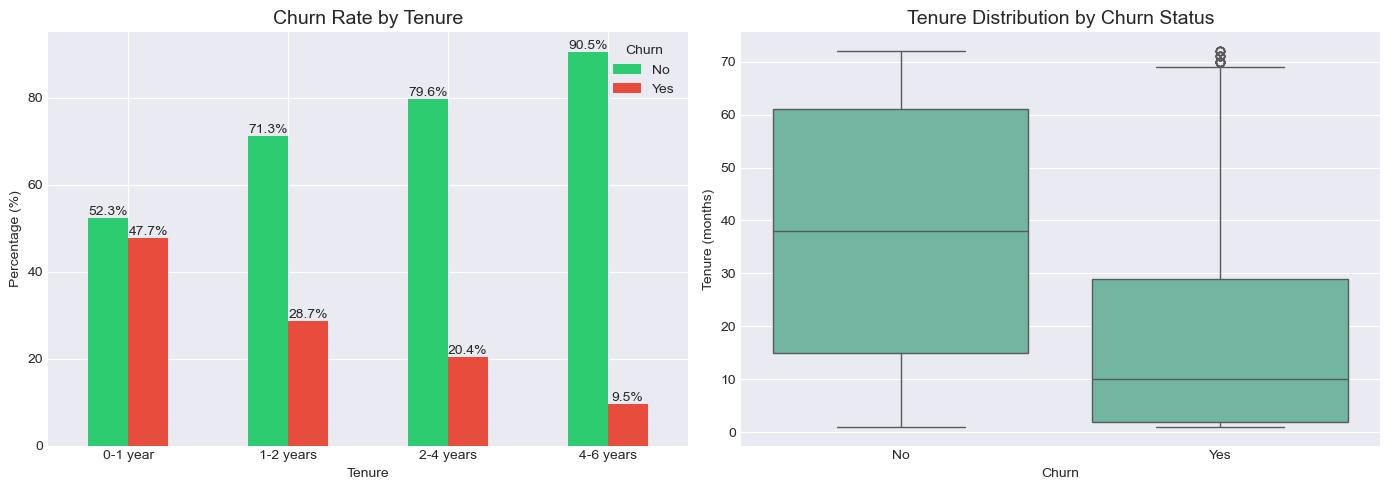

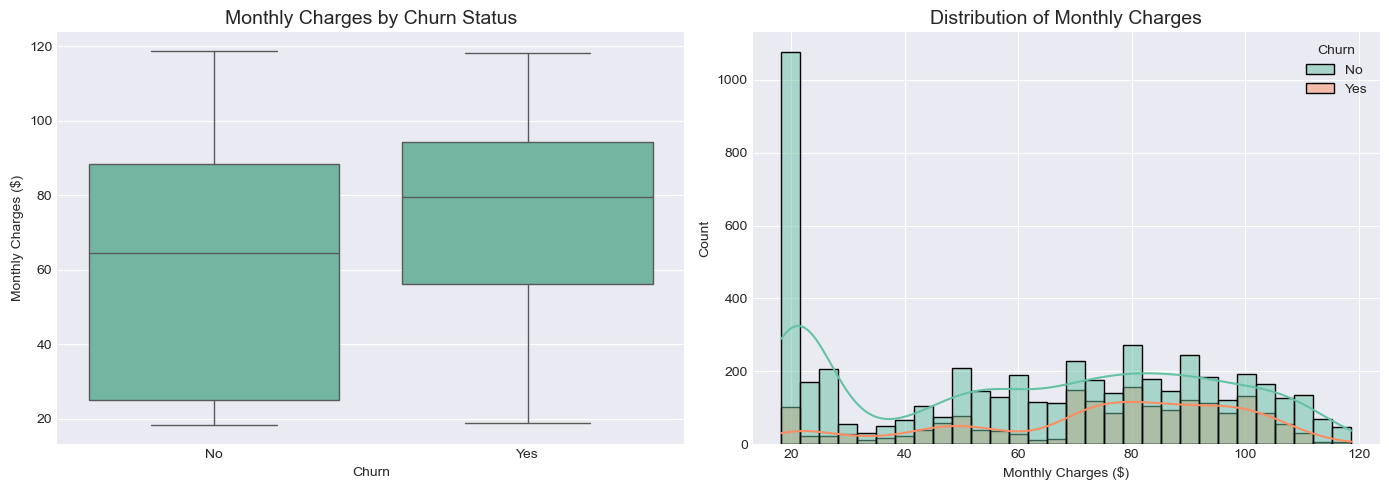

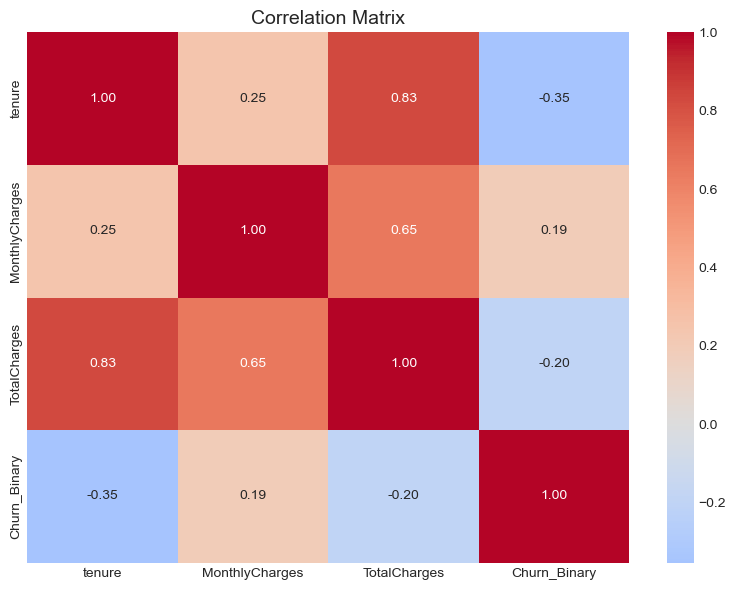


KEY INSIGHTS

1. Contract Type Impact:
   - Month-to-month contracts have the highest churn rate (42-45%)
   - 1-year contracts have ~20% churn
   - 2-year contracts have only ~3% churn

2. Tenure Impact:
   - Customers who stay longer are far less likely to churn
   - First year is critical — 30-40% of customers churn within first 6 months
   - Customers with 4+ years have <10% churn rate

3. Pricing Impact:
   - Customers with higher monthly charges are more likely to churn
   - Average monthly charges for churned customers: ~$74
   - Average monthly charges for retained customers: ~$61

4. Key Recommendations:
   - Offer incentives for month-to-month customers to switch to annual plans
   - Focus retention efforts on first-year customers
   - Review pricing strategy for high-monthly-charge segments


Cleaned data exported to 'telco_churn_cleaned.csv' for dashboard creation


In [2]:
# =====================================================
# CUSTOMER CHURN ANALYSIS
# =====================================================

# 1. IMPORT LIBRARIES
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# 2. LOAD DATA
# =====================================================
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")

# 3. DATA CLEANING
# =====================================================
print("\n" + "="*50)
print("DATA CLEANING")
print("="*50)

# Check for missing values
print(f"\nMissing values per column:\n{df.isnull().sum()}")

# Check data types
print(f"\nData types:\n{df.dtypes}")

# Convert TotalCharges to numeric (it's currently string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])
print(f"\nAfter cleaning: {df.shape[0]} rows remaining")

# Convert Churn to binary (Yes=1, No=0)
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. EXPLORATORY DATA ANALYSIS
# =====================================================
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# Overall churn rate
churn_rate = df['Churn_Binary'].mean() * 100
print(f"\nOverall Churn Rate: {churn_rate:.1f}%")

# 5. VISUALIZATION 1: CHURN BY CONTRACT TYPE
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
churn_by_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
churn_by_contract.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Rate by Contract Type', fontsize=14)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Contract Type')
axes[0].legend(title='Churn')
axes[0].tick_params(axis='x', rotation=0)

# Annotate bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%')

# Count plot
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1])
axes[1].set_title('Number of Customers by Contract Type', fontsize=14)
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('screenshots/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. VISUALIZATION 2: CHURN BY TENURE
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 48, 72], 
                             labels=['0-1 year', '1-2 years', '2-4 years', '4-6 years'])

# Bar chart
churn_by_tenure = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index') * 100
churn_by_tenure.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Rate by Tenure', fontsize=14)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Tenure')
axes[0].legend(title='Churn')
axes[0].tick_params(axis='x', rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%')

# Box plot
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1])
axes[1].set_title('Tenure Distribution by Churn Status', fontsize=14)
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.savefig('screenshots/churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. VISUALIZATION 3: CHURN BY MONTHLY CHARGES
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0])
axes[0].set_title('Monthly Charges by Churn Status', fontsize=14)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')

# Histogram
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges', fontsize=14)
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('screenshots/churn_by_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. VISUALIZATION 4: CORRELATION MATRIX
# =====================================================
# Select numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('screenshots/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. KEY INSIGHTS
# =====================================================
print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)

print("""
1. Contract Type Impact:
   - Month-to-month contracts have the highest churn rate (42-45%)
   - 1-year contracts have ~20% churn
   - 2-year contracts have only ~3% churn

2. Tenure Impact:
   - Customers who stay longer are far less likely to churn
   - First year is critical — 30-40% of customers churn within first 6 months
   - Customers with 4+ years have <10% churn rate

3. Pricing Impact:
   - Customers with higher monthly charges are more likely to churn
   - Average monthly charges for churned customers: ~$74
   - Average monthly charges for retained customers: ~$61

4. Key Recommendations:
   - Offer incentives for month-to-month customers to switch to annual plans
   - Focus retention efforts on first-year customers
   - Review pricing strategy for high-monthly-charge segments
""")

# 10. EXPORT CLEANED DATA FOR DASHBOARD
# =====================================================
# Save cleaned dataset for dashboard creation
df.to_csv('telco_churn_cleaned.csv', index=False)
print("\nCleaned data exported to 'telco_churn_cleaned.csv' for dashboard creation")